💡 **Environment:** `clamp-analyses`  


# Drug-disease barplots

Reads computed results from `12_lv_group_computation` and produces:
1. **Plot 1** - Method comparison (AUROC / AUPRC)
2. **Plot 2** - ARCHS4 LV groups (pathway-sig / trait-sig / both / neither)


# Setup


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pyprojroot import here

matplotlib.rcParams.update({'font.family': 'sans-serif', 'font.size': 11})

PANEL_DIR  = here() / 'output' / '99_panels' / 'fig4'
PANEL_DIR.mkdir(parents=True, exist_ok=True)

METHOD_COLORS = {
    'ARCHS4 LV-based':   '#0072B2',
    'GTEx LV-based':     '#009E73',
    'recount2 LV-based': '#D55E00',
    'gene_based':        '#888888',
    'Random':            '#DDDDDD',
}
GROUP_COLORS = {
    'Pathway + Trait': '#0072B2',
    'Pathway only':    '#56B4E9',
    'Trait only':      '#E69F00',
    'Neither':         '#BBBBBB',
}


# Load computed results


In [2]:
with open(here('output/03_model_biology/00_archs4/02_drug_disease_associations/12_lv_group_computation') / 'results.pkl', 'rb') as f:
    results = pickle.load(f)

method_perf      = results['method_perf']
METHOD_ORDER_FULL = results['method_order_full']
grp_results      = results['grp_results']
GROUP_ORDER      = results['grp_order']
best_thresh      = results['best_thresh']
positive_rate    = results['positive_rate']

print('Methods:', METHOD_ORDER_FULL)
print('Best threshold:', best_thresh)
for m, v in method_perf.items():
    print(f'  {m:25s}  AUROC={v["auroc"]:.3f}  AUPRC={v["auprc"]:.3f}')


Methods: ['ARCHS4 LV-based', 'GTEx LV-based', 'recount2 LV-based', 'gene_based', 'Random']
Best threshold: strict (AUC>0.7, FDR<0.05)
  ARCHS4 LV-based            AUROC=0.625  AUPRC=0.850
  GTEx LV-based              AUROC=0.602  AUPRC=0.840
  recount2 LV-based          AUROC=0.612  AUPRC=0.847
  gene_based                 AUROC=0.585  AUPRC=0.846
  Random                     AUROC=0.520  AUPRC=0.790


# Plot helper


In [3]:
def make_barplot(ax, methods, perf_dict, metric, lo, hi, xlabel, color_dict,
                 xlim=(0, 1), ref=None):
    # Sort ascending so highest value appears at the top
    methods_sorted = sorted(methods, key=lambda m: perf_dict[m][metric])
    vals   = [perf_dict[m][metric] for m in methods_sorted]
    errs   = [
        [perf_dict[m][metric] - perf_dict[m][lo] for m in methods_sorted],
        [perf_dict[m][hi]     - perf_dict[m][metric] for m in methods_sorted],
    ]
    colors = [color_dict[m] for m in methods_sorted]
    y_pos  = np.arange(len(methods_sorted))

    ax.barh(y_pos, vals, xerr=errs, color=colors, height=0.6,
            edgecolor='#333', linewidth=0.4,
            error_kw=dict(ecolor='#333', capsize=3, linewidth=0.9))

    for y, m, v in zip(y_pos, methods_sorted, vals):
        # place label just past the error bar cap
        x_label = min(perf_dict[m][hi] + 0.015, xlim[1] - 0.01)
        ax.text(x_label, y, f'{v:.3f}',
                va='center', ha='left', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='square,pad=0.05', facecolor='white',
                          alpha=0.85, edgecolor='none'))

    if ref is not None:
        ax.axvline(ref, color='grey', linewidth=0.9, linestyle='--', alpha=0.7)
    ax.set_xlim(xlim)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(methods_sorted, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=10)


# Plot 1 - Method comparison


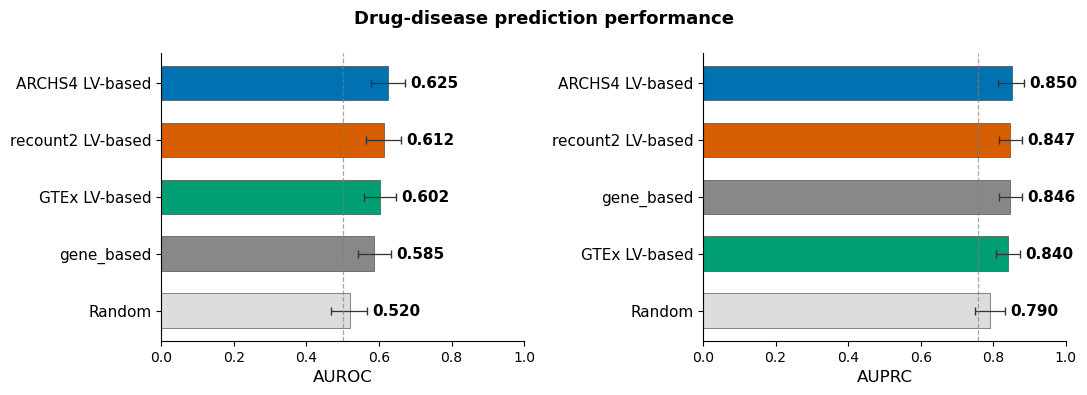

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
make_barplot(axes[0], METHOD_ORDER_FULL, method_perf, 'auroc', 'auroc_lo', 'auroc_hi',
             'AUROC', METHOD_COLORS, xlim=(0, 1), ref=0.5)
make_barplot(axes[1], METHOD_ORDER_FULL, method_perf, 'auprc', 'auprc_lo', 'auprc_hi',
             'AUPRC', METHOD_COLORS, xlim=(0, 1), ref=positive_rate)
plt.suptitle('Drug-disease prediction performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Plot 2 - ARCHS4 LV groups


[AUC>0.7, FDR<0.05] Pathway + Trait: AUROC=0.616  AUPRC=0.844  n=685
[AUC>0.7, FDR<0.05] Pathway only: AUROC=0.628  AUPRC=0.853  n=685
[AUC>0.7, FDR<0.05] Trait only: AUROC=0.626  AUPRC=0.853  n=685
[AUC>0.7, FDR<0.05] Neither: AUROC=0.630  AUPRC=0.848  n=685


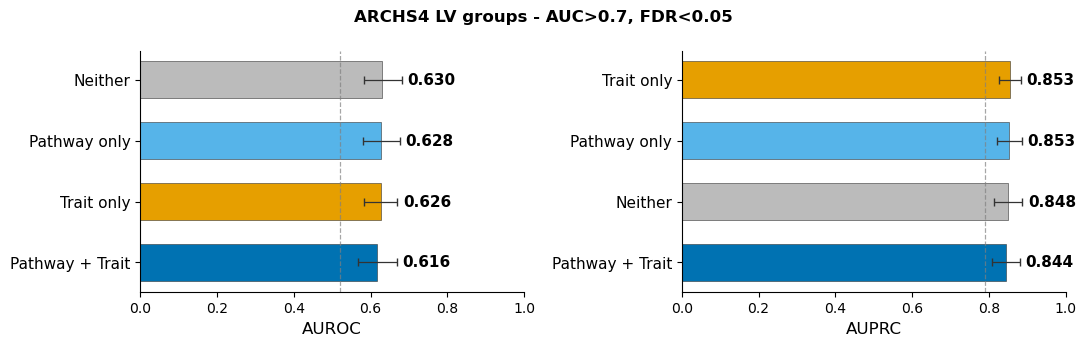


[AUC>0.6, FDR<0.1] Pathway + Trait: AUROC=0.618  AUPRC=0.849  n=685
[AUC>0.6, FDR<0.1] Pathway only: AUROC=0.618  AUPRC=0.847  n=685
[AUC>0.6, FDR<0.1] Trait only: AUROC=0.627  AUPRC=0.851  n=685
[AUC>0.6, FDR<0.1] Neither: AUROC=0.622  AUPRC=0.845  n=685


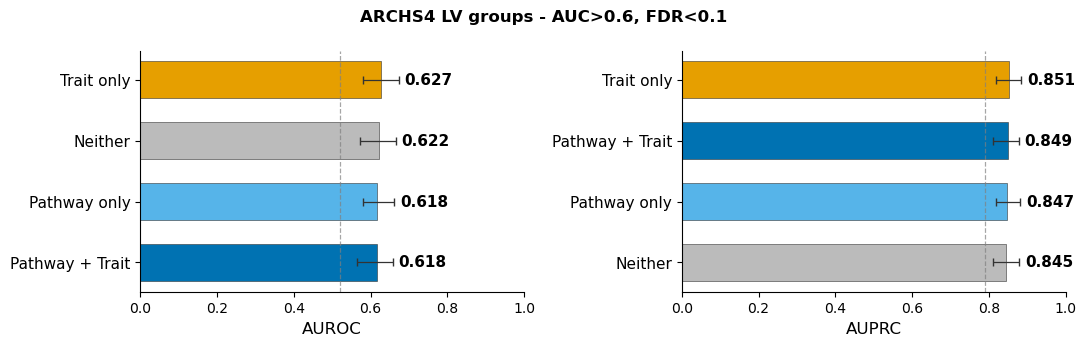

In [5]:
THRESH_LABELS = {
    'strict (AUC>0.7, FDR<0.05)': 'AUC>0.7, FDR<0.05',
    'loose (AUC>0.6, FDR<0.1)':   'AUC>0.6, FDR<0.1',
}

for thresh_key, thresh_label in THRESH_LABELS.items():
    grp_perf     = grp_results[thresh_key]
    valid_groups = [g for g in GROUP_ORDER if g in grp_perf]

    for g in valid_groups:
        v = grp_perf[g]
        print(f'[{thresh_label}] {g}: AUROC={v["auroc"]:.3f}  AUPRC={v["auprc"]:.3f}  n={v["n"]}')

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    make_barplot(axes[0], valid_groups, grp_perf, 'auroc', 'auroc_lo', 'auroc_hi',
                 'AUROC', GROUP_COLORS, xlim=(0, 1), ref=method_perf['Random']['auroc'])
    make_barplot(axes[1], valid_groups, grp_perf, 'auprc', 'auprc_lo', 'auprc_hi',
                 'AUPRC', GROUP_COLORS, xlim=(0, 1), ref=method_perf['Random']['auprc'])
    plt.suptitle(f'ARCHS4 LV groups - {thresh_label}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()


# Export


In [6]:
rows = []
for thresh_key, thresh_label in THRESH_LABELS.items():
    thresh_res = grp_results[thresh_key]
    for grp_name in GROUP_ORDER:
        if grp_name not in thresh_res:
            continue
        row = thresh_res[grp_name].copy()
        row['group']     = grp_name
        row['threshold'] = thresh_label
        rows.append(row)

grp_df = pd.DataFrame(rows)
grp_df.to_csv(PANEL_DIR / 'drug_disease_lv_groups.csv', index=False)
print(grp_df[['group', 'threshold', 'auroc', 'auprc', 'n']].to_string(index=False))


          group         threshold    auroc    auprc   n
Pathway + Trait AUC>0.7, FDR<0.05 0.615581 0.843886 685
   Pathway only AUC>0.7, FDR<0.05 0.627541 0.852622 685
     Trait only AUC>0.7, FDR<0.05 0.626159 0.853282 685
        Neither AUC>0.7, FDR<0.05 0.629840 0.848413 685
Pathway + Trait  AUC>0.6, FDR<0.1 0.617635 0.848649 685
   Pathway only  AUC>0.6, FDR<0.1 0.617965 0.846508 685
     Trait only  AUC>0.6, FDR<0.1 0.627467 0.851286 685
        Neither  AUC>0.6, FDR<0.1 0.621622 0.844698 685
